# Free-Living vs. Particle-Attached WS/DGAT Biosynthetic Potential in the Deep Ocean (Malaspina Expedition)

**Author:** Virginia Galván, PhD
**Associated publication / thesis reference:** doctoral thesis, Chapter I — Section 7.3.7.3, Figure 15

---

## Biological context

Notebooks 04 and 05 characterized WS/DGAT biosynthetic potential (Pfam domain **PF03007**) across marine and terrestrial sediment metagenomes. This notebook moves to a different marine habitat and a different ecological question: the deep ocean (bathypelagic zone, 2,000–4,000 m), sampled by the **Malaspina 2010 Expedition** (Salazar et al. 2016), the first global systematic survey of the deep ocean microbiome.

At each station, Malaspina separated the microbial community into two size fractions: **free-living** (0.2–0.8 µm) and **particle-attached** (0.8–20 µm). These fractions are known to differ substantially in taxonomic and functional composition — particle-attached communities colonize sinking organic aggregates ("marine snow"), which create transient pockets of high carbon availability, a context favorable to carbon-storage strategies such as neutral lipid biosynthesis. This notebook tests whether WS/DGAT relative abundance differs between the two fractions, using a **paired design**: each station contributes one free-living and one particle-attached sample, so the appropriate test is the Wilcoxon signed-rank test (not Mann-Whitney, which assumes independent groups).

## 0. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

DATA_DIR = '../data' if os.path.exists('../data') else '.'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 150
})

FRACTION_COLORS = {'free_living': '#4292c6', 'particle_attached': '#08306b'}
FRACTION_LABELS = {'free_living': 'Free-living\n(0.2–0.8 µm)', 'particle_attached': 'Particle-attached\n(0.8–20 µm)'}

print(f'Data directory: {DATA_DIR}')

Data directory: .


## 1. Load and process data

**Pfam domains used (13 total):** same target (PF03007) and 12 single-copy ribosomal reference domains as Notebooks 01, 04, and 05.

**Data source:** Pfam domain hit counts for 50 Malaspina deep-ocean metagenomes — 25 stations, each with a free-living and a particle-attached sample (IMG/M). Station, fraction (encoded by filter pore size: 0.2 µm = free-living, 0.8 µm = particle-attached), basin, water mass, depth, and coordinates come from the official Malaspina sample sheet (JGI/IMG project metadata).

In [2]:
gene_counts = pd.read_csv(f'{DATA_DIR}/malaspina_gene_counts_repo1.csv', index_col='sample_code')
metadata = pd.read_csv(f'{DATA_DIR}/malaspina_metadata_repo1.csv')

print(f'Gene counts table: {gene_counts.shape[0]} samples x {gene_counts.shape[1]} Pfam domains')
print(f'Metadata table (official Malaspina samples): {metadata.shape[0]} samples')
gene_counts.head()

Gene counts table: 50 samples x 13 Pfam domains
Metadata table (official Malaspina samples): 50 samples


,pfam03007,pfam00189,pfam00252,pfam00453,pfam00542,pfam00831,pfam00886,pfam01016,pfam01196,pfam01245,pfam01250,pfam01281,pfam01649
sample_code,,,,,,,,,,,,,
MP0103,40,688,1101,502,466,644,438,454,584,518,481,442,442
MP0104,42,202,246,331,197,208,217,221,282,220,252,241,186
MP0144,53,195,150,135,142,138,112,168,138,159,145,116,127
MP0145,34,253,412,251,183,266,173,169,189,192,215,115,162
MP0203,145,508,603,355,441,471,350,430,424,371,399,355,301


### 1.1 Compute relative abundance

Relative abundance of PF03007 is the mean of 12 ratios (PF03007 / each ribosomal marker), same methodology as Notebooks 01, 04, and 05. QC threshold: a sample is retained only if at least 6 of its 12 ratios are computable — consistent with the rest of this portfolio.

In [3]:
pfam_target = 'pfam03007'
pfams_ref = [c for c in gene_counts.columns if c != pfam_target]

ratios = pd.DataFrame(index=gene_counts.index)
numerator = gene_counts[pfam_target].astype(float)

for ref in pfams_ref:
    with np.errstate(divide='ignore', invalid='ignore'):
        r = numerator / gene_counts[ref].astype(float)
        r = r.replace([np.inf, -np.inf], np.nan)
    ratios[f'ratio_over_{ref}'] = r

ratios['mean_ratio'] = ratios.mean(axis=1, skipna=True)
ratios['std_ratio'] = ratios.std(axis=1, ddof=1, skipna=True)
ratios['n_valid'] = ratios.iloc[:, :len(pfams_ref)].notna().sum(axis=1)

MIN_VALID_RATIOS = 6
n_failed_qc = (ratios['n_valid'] < MIN_VALID_RATIOS).sum()
print(f'Samples failing QC (n_valid < {MIN_VALID_RATIOS}/12): {n_failed_qc}')

ratios = ratios[ratios['n_valid'] >= MIN_VALID_RATIOS]
df = gene_counts.join(ratios[['mean_ratio', 'std_ratio', 'n_valid']], how='inner').join(
    metadata.set_index('sample_code')
)
print(f'Samples passing QC: {df.shape[0]} / {gene_counts.shape[0]}')
df[['station', 'fraction', 'basin', 'mean_ratio', 'std_ratio', 'n_valid']].head()

Samples failing QC (n_valid < 6/12): 0
Samples passing QC: 50 / 50


,station,fraction,basin,mean_ratio,std_ratio,n_valid
sample_code,,,,,,
MP0103,7.0,free_living,Canary basin,0.075950,0.016090,12
MP0104,7.0,particle_attached,Canary basin,0.184237,0.026973,12
MP0144,10.0,particle_attached,Canary basin,0.376736,0.054064,12
MP0145,10.0,free_living,Canary basin,0.173695,0.051090,12
MP0203,13.0,particle_attached,Canary basin,0.359075,0.063112,12


### 1.2 Organize by station

Pivoting free-living and particle-attached values side by side by station sets up the paired comparison used in Section 2 and 3.

In [4]:
pivot = df.pivot_table(index='station', columns='fraction', values='mean_ratio')
paired = pivot[['free_living', 'particle_attached']].copy()

print(f'{len(paired)} stations, {len(df)} metagenomes')

25 stations, 50 metagenomes


## 2. Figure 5 — Paired comparison across stations

Each line connects the free-living and particle-attached relative abundance measured at the same station.

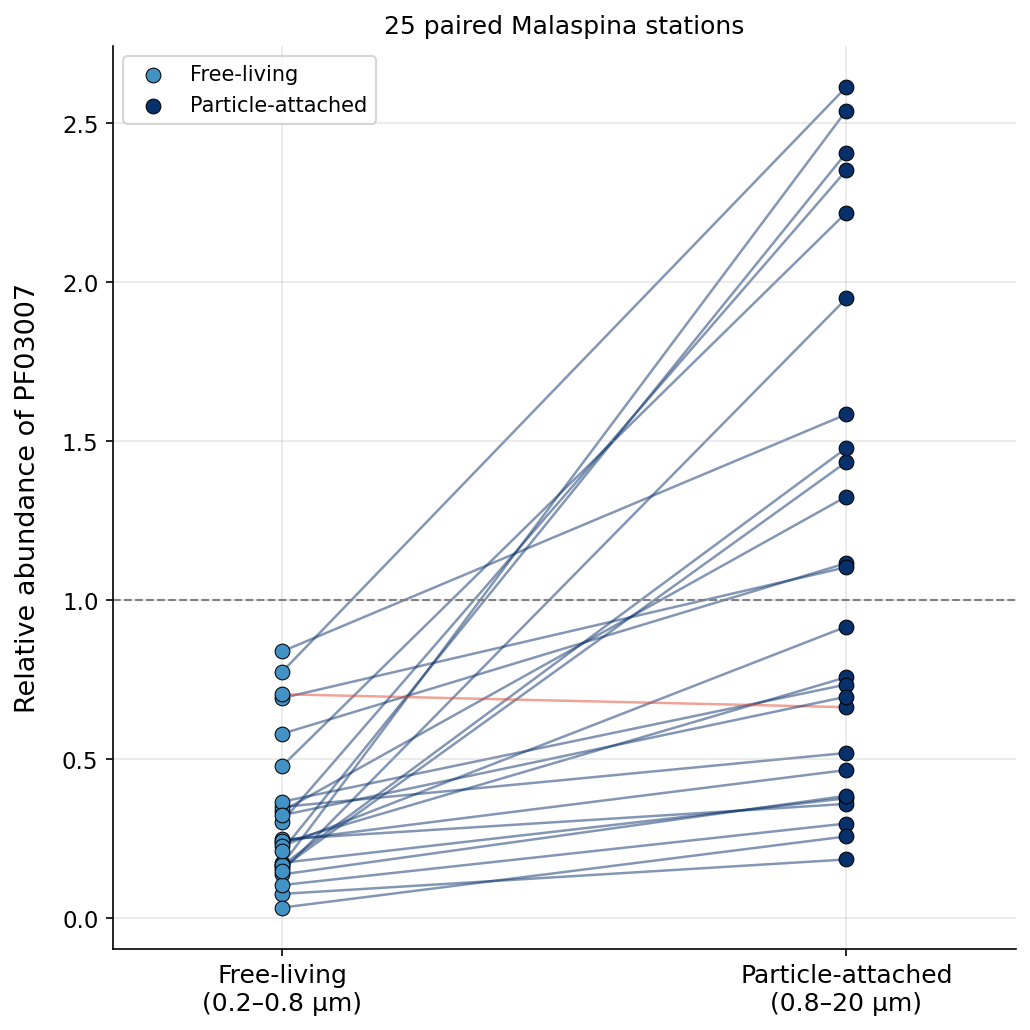

Particle-attached > free-living in 24/25 stations (96.0%)


In [5]:
fig, ax = plt.subplots(figsize=(7, 7))

for station, row in paired.iterrows():
    color = '#08306b' if row['particle_attached'] > row['free_living'] else '#e34a33'
    ax.plot([0, 1], [row['free_living'], row['particle_attached']],
            color=color, alpha=0.5, linewidth=1.2, zorder=1)

ax.scatter([0]*len(paired), paired['free_living'], color=FRACTION_COLORS['free_living'],
           s=50, edgecolor='black', linewidth=0.5, zorder=2, label='Free-living')
ax.scatter([1]*len(paired), paired['particle_attached'], color=FRACTION_COLORS['particle_attached'],
           s=50, edgecolor='black', linewidth=0.5, zorder=2, label='Particle-attached')

ax.axhline(1, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(-0.3, 1.3)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Free-living\n(0.2–0.8 µm)', 'Particle-attached\n(0.8–20 µm)'], fontsize=12)
ax.set_ylabel('Relative abundance of PF03007', fontsize=13, labelpad=10)
ax.set_title(f'{len(paired)} paired Malaspina stations', fontsize=12)
ax.legend(loc='upper left', frameon=True, fontsize=10)
plt.tight_layout()

plt.savefig(f'{DATA_DIR}/figure5_malaspina_paired_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{DATA_DIR}/figure5_malaspina_paired_comparison.svg', bbox_inches='tight')
plt.show()

n_increase = (paired['particle_attached'] > paired['free_living']).sum()
print(f'Particle-attached > free-living in {n_increase}/{len(paired)} stations ({n_increase/len(paired)*100:.1f}%)')

## 3. Wilcoxon signed-rank test

Free-living and particle-attached samples are paired by station, so the appropriate test is the Wilcoxon signed-rank test (not Mann-Whitney, which assumes independent groups).

In [6]:
stat, p_value = wilcoxon(paired['particle_attached'], paired['free_living'])

print(f'N stations: {len(paired)}')
print(f'Median free-living:      {paired["free_living"].median():.3f}')
print(f'Median particle-attached: {paired["particle_attached"].median():.3f}')
print(f'\nWilcoxon signed-rank statistic = {stat:.1f}, p = {p_value:.2e}')

N stations: 25
Median free-living:      0.243
Median particle-attached: 0.917

Wilcoxon signed-rank statistic = 1.0, p = 1.19e-07


**Result:** relative WS/DGAT abundance is significantly higher in particle-attached communities than in free-living ones (p < 0.001). The effect is strikingly consistent: 24 of 25 paired stations show higher abundance in the particle-attached fraction — the single exception is station 144 (Canary basin), where the two fractions are nearly equal.

Sinking organic particles ("marine snow"; Azam & Long 2001) create transient, carbon-rich microenvironments that favor microbial carbon-storage strategies, including neutral lipid biosynthesis via WS/DGAT, whereas free-living cells in the surrounding water column experience comparatively carbon-poor, more stable conditions. Free-living and particle-attached bathypelagic prokaryotes are known to be ecologically and phylogenetically distinct lifestyles (Salazar et al. 2015), and the abundance difference found here holds consistently across ocean basins (Section 4), arguing against it being an artifact of any single region or water mass.

## 4. Basin-level context

Ocean basins represented across the 25 paired stations, to check the pattern above isn't concentrated in one region:

In [7]:
basin_lookup = df.drop_duplicates('station').set_index('station')['basin']
paired_with_basin = paired.join(basin_lookup)
basin_summary = paired_with_basin.groupby('basin').size().sort_values(ascending=False)
print('Stations by basin:')
print(basin_summary.to_string())

Stations by basin:
basin
Brazil basin              5
Canary basin              5
Agulhas-Cape basin        3
Pacific basin             3
Out of basins             3
Fiji basin                1
Guatemala basin           1
Mid Indian basin          1
Madagascar basin          1
North American basin      1
South Australian basin    1


## 5. Export summary table

In [8]:
summary = df.reset_index()[['sample_code', 'metagenome_id', 'station', 'fraction', 'basin', 'watermass',
                             'depth_m', 'latitude', 'longitude', 'mean_ratio', 'std_ratio', 'n_valid']].copy()
summary.columns = ['Sample code', 'Metagenome ID (IMG)', 'Station', 'Fraction', 'Basin', 'Water mass', 'Depth (m)',
                    'Latitude', 'Longitude', 'Rel. abundance (mean)', 'Rel. abundance (SD)', 'N valid ratios']
summary[['Rel. abundance (mean)', 'Rel. abundance (SD)']] = \
    summary[['Rel. abundance (mean)', 'Rel. abundance (SD)']].round(3)
summary = summary.sort_values(['Station', 'Fraction'])

summary.to_csv(f'{DATA_DIR}/malaspina_summary_table.csv', index=False)
print('Exported: malaspina_summary_table.csv')
summary.head(10)

Exported: malaspina_summary_table.csv


,Sample code,Metagenome ID (IMG),Station,Fraction,Basin,Water mass,Depth (m),Latitude,Longitude,Rel. abundance (mean),Rel. abundance (SD),N valid ratios
0,MP0103,3300001060,7.0,free_living,Canary basin,NADW,-4005.0,21.51,-23.45,0.076,0.016,12
1,MP0104,3300001054,7.0,particle_attached,Canary basin,NADW,-4005.0,21.51,-23.45,0.184,0.027,12
3,MP0145,3300000966,10.0,free_living,Canary basin,NADW,-4002.0,14.52,-26.00,0.174,0.051,12
2,MP0144,3300000967,10.0,particle_attached,Canary basin,NADW,-4002.0,14.52,-26.00,0.377,0.054,12
5,MP0204,3300001125,13.0,free_living,Canary basin,NADW,-4003.0,7.33,-26.00,0.248,0.057,12
4,MP0203,3300001091,13.0,particle_attached,Canary basin,NADW,-4003.0,7.33,-26.00,0.359,0.063,12
7,MP0262,3300001574,17.0,free_living,Brazil basin,NADW,-4002.0,-3.03,-27.33,0.236,0.053,12
6,MP0261,3300001122,17.0,particle_attached,Brazil basin,NADW,-4002.0,-3.03,-27.33,0.757,0.181,12
9,MP0327,3300001106,20.0,free_living,Brazil basin,NADW,-4001.0,-9.12,-30.19,0.137,0.034,12
8,MP0326,3300001013,20.0,particle_attached,Brazil basin,NADW,-4001.0,-9.12,-30.19,0.385,0.064,12


## 6. Key findings

1. **Particle-attached microbial communities carry significantly more WS/DGAT biosynthetic potential than free-living ones in the deep ocean.** Across 25 paired Malaspina stations (2,000–4,000 m depth), relative PF03007 abundance was higher in the particle-attached fraction in 24/25 stations (Wilcoxon signed-rank p < 0.001).

2. **The pattern is remarkably consistent across ocean basins**, spanning stations from the Canary, Brazil, Agulhas-Cape, Madagascar, Mid Indian, South Australian, Pacific, and North American basins — this is not a regional artifact.

3. **The effect size is large, not just statistically significant.** Median relative abundance is roughly 4x higher in particle-attached samples (0.92) than in free-living ones (0.24).

**Biological implication:** organic particle microhabitats ("marine snow") appear to be hotspots of neutral lipid biosynthetic potential in the deep ocean, consistent with a carbon-storage strategy favored by transient carbon-rich conditions — reinforcing particle-attached deep-sea communities as a specific, promising target for bioprospecting.

---

## References

- Galván V. et al. (2023). High potential for the biosynthesis of neutral lipid storage compounds in chronically-polluted subantarctic sediments. *PLOS ONE*, 18(7). https://doi.org/10.1371/journal.pone.0288509
- Acinas SG, Sánchez P, Salazar G, Cornejo-Castillo FM, Sebastián M, Logares R, et al. (2021). Deep ocean metagenomes provide insight into the metabolic architecture of bathypelagic microbial communities. *Communications Biology*, 4, 604. https://doi.org/10.1038/s42003-021-02112-2
- Salazar G, Cornejo-Castillo FM, Benítez-Barrios V, Fraile-Nuez E, Álvarez-Salgado XA, Duarte CM, et al. (2016). Global diversity and biogeography of deep-sea pelagic prokaryotes. *The ISME Journal*, 10(3), 596–608. https://doi.org/10.1038/ismej.2015.137
- Salazar G, Cornejo-Castillo FM, Borrull E, Diez-Vives C, Vaqué D, Arrieta JM, et al. (2015). Particle-association lifestyle is a phylogenetically conserved trait in bathypelagic prokaryotes. *Molecular Ecology*, 24(22), 5692–5706. https://doi.org/10.1111/mec.13419
- Azam F, Long RA (2001). Sea snow microcosms. *Nature*, 414(6863), 495–498. https://doi.org/10.1038/35107174
- Chen IA, Chu K, Palaniappan K, et al. (2021). The IMG/M data management and analysis system v.6.0: new tools and advanced capabilities. *Nucleic Acids Research*, 49(D1), D751–D763. https://doi.org/10.1093/nar/gkaa939